In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Unemployment.csv")

In [14]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [15]:
for col in df.columns:
    if 'date' in col.lower():
        df[col] = pd.to_datetime(df[col])
        date_col = col

print("Using date column:", date_col)

Using date column: Date


C:\Users\surya\AppData\Local\Temp\ipykernel_6140\2465563174.py:3: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col])


In [16]:
for col in df.columns:
    if 'unemployment' in col.lower():
        unemp_col = col

print("Using unemployment column:", unemp_col)

Using unemployment column: Estimated Unemployment Rate (%)


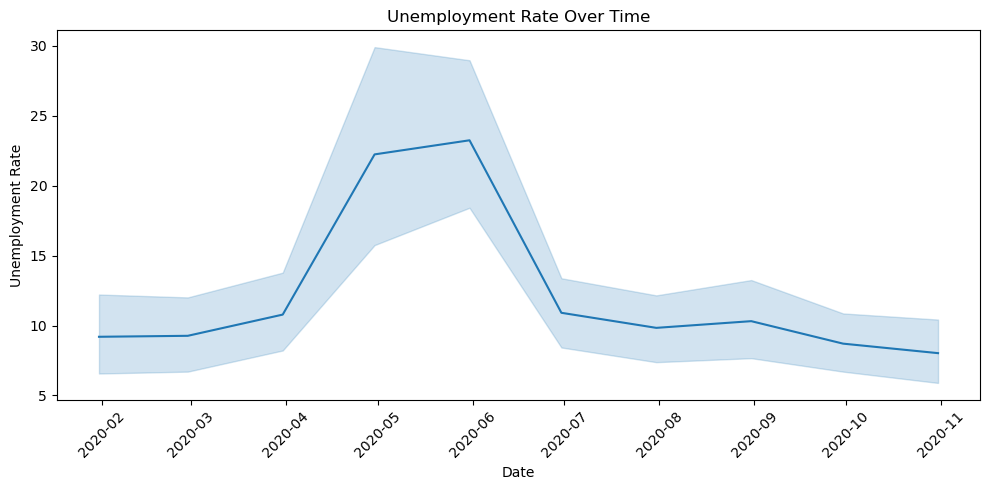

In [17]:
plt.figure(figsize=(10,5))

sns.lineplot(x=date_col, y=unemp_col, data=df)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

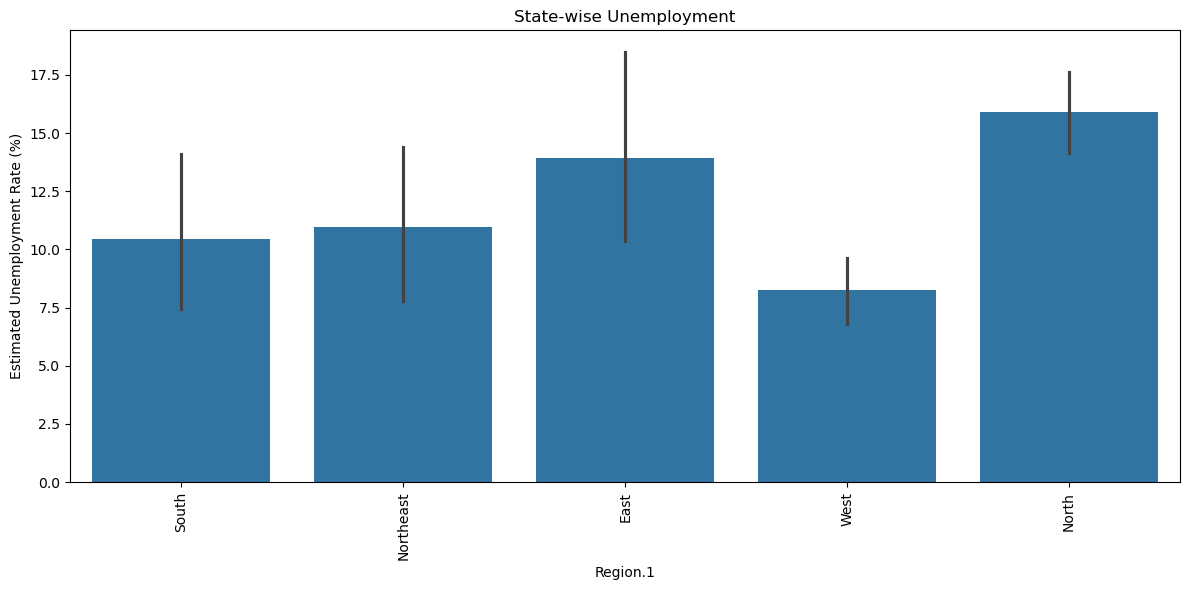

In [18]:
for col in df.columns:
    if 'region' in col.lower():
        region_col = col

plt.figure(figsize=(12,6))

sns.barplot(x=region_col, y=unemp_col, data=df)

plt.xticks(rotation=90)
plt.title("State-wise Unemployment")

plt.tight_layout()
plt.show()

In [19]:
top_states = df.groupby(region_col)[unemp_col].mean().sort_values(ascending=False).head()

print("Top 5 States with Highest Unemployment:")
print(top_states)

Top 5 States with Highest Unemployment:
Region.1
North        15.889620
East         13.916000
Northeast    10.950263
South        10.454667
West          8.239000
Name: Estimated Unemployment Rate (%), dtype: float64


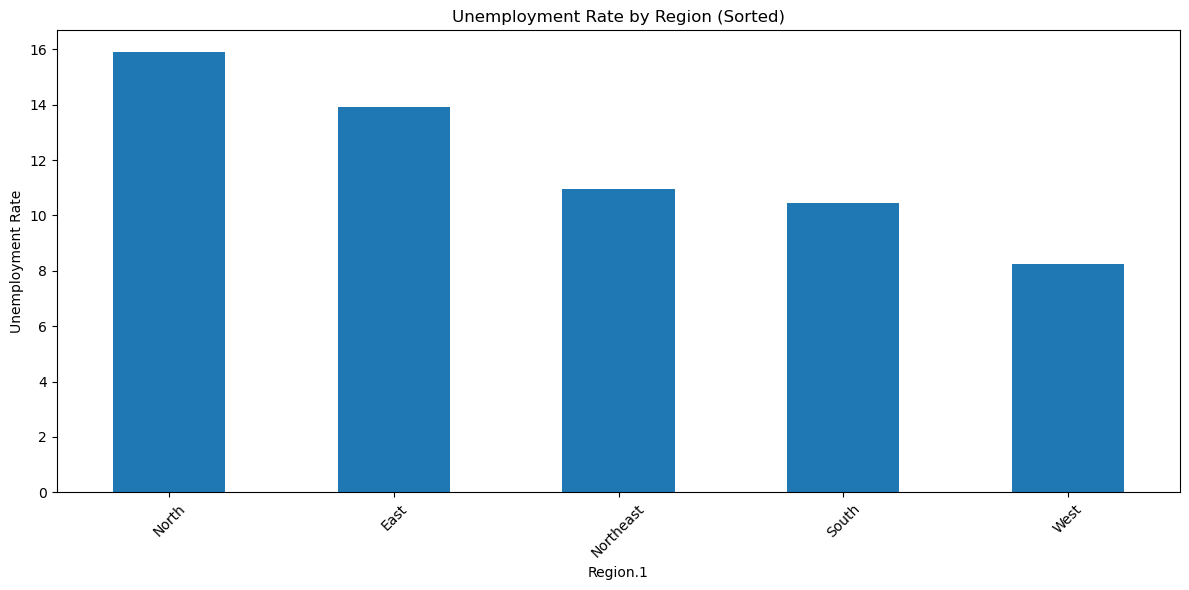

In [20]:
sorted_df = df.groupby(region_col)[unemp_col].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sorted_df.plot(kind='bar')

plt.title("Unemployment Rate by Region (Sorted)")
plt.ylabel("Unemployment Rate")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

This project analyzes unemployment trends using Python. The analysis shows that unemployment rates vary across different regions. Some regions consistently show higher unemployment, and there was a noticeable increase during certain periods such as COVID-19.